# Sms classification as spam or not

## Data Dictionary

This corpus has been collected from free or free for research sources at the Web:

- A collection of between 425 SMS spam messages extracted manually from the Grumbletext Web site. This is a UK forum in which cell phone users make public claims about SMS spam messages, most of them without reporting the very spam message received. The identification of the text of spam messages in the claims is a very hard and time-consuming task, and it involved carefully scanning hundreds of web pages. The Grumbletext Web site is: http://www.grumbletext.co.uk/
- A list of 450 SMS ham messages collected from Caroline Tag's PhD Theses available at http://etheses.bham.ac.uk/253/1/Tagg09PhD.pdf
- A subset of 3,375 SMS ham messages of the NUS SMS Corpus (NSC), which is a corpus of about 10,000 legitimate messages collected for research at the Department of Computer Science at the National University of Singapore. The messages largely originate from Singaporeans and mostly from students attending the University. These messages were collected from volunteers who were made aware that their contributions were going to be made publicly available. The NUS SMS Corpus is avalaible at: http://www.comp.nus.edu.sg/~rpnlpir/downloads/corpora/smsCorpus/
- The amount of 1,002 SMS ham messages and 322 spam messages extracted from the SMS Spam Corpus v.0.1 Big created by JosÈ MarÌa GÛmez Hidalgo and public available at: http://www.esp.uem.es/jmgomez/smsspamcorpus/


## Step 1. Importing libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [63]:
df = pd.read_csv("smsspamcollection.csv", header=None, names=["Class", "sms"])

In [64]:
df.head()

,Class,sms
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [65]:
def binary_map(x):
    return 0 if x == "ham" else 1


df["Class"] = df["Class"].map(lambda x: binary_map(x))
df.head()

,Class,sms
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [66]:
# Checking for null
100 * df.isna().mean()

Class    0.0
sms      0.0
dtype: float64

In [67]:
X = df["sms"]
y = df["Class"]

## Building Model

In [68]:
# Splitting into X_train and X_test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.7, test_size=0.3, random_state=100
)

In [69]:
X_train.head()

3730                             I'm at home. Please call
974                          what is your account number?
4583    Wow didn't think it was that common. I take it...
4028        Yes, princess. Are you going to make me moan?
1447    Looks like u wil b getting a headstart im leav...
Name: sms, dtype: object

In [70]:
y_train.head(10)

3730    0
974     0
4583    0
4028    0
1447    0
1921    0
3443    1
1132    0
5543    0
3169    0
Name: Class, dtype: int64

In [71]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(stop_words="english")

In [72]:
vectorizer.fit(X_train)

CountVectorizer(stop_words='english')

In [73]:
vectorizer.vocabulary_

{'home': 3114,
 'account': 733,
 'number': 4355,
 'wow': 6798,
 'didn': 2076,
 'think': 6112,
 'common': 1733,
 'ur': 6439,
 'freak': 2673,
 'unless': 6410,
 'chop': 1630,
 'yes': 6867,
 'princess': 4837,
 'going': 2849,
 'make': 3897,
 'moan': 4080,
 'looks': 3775,
 'like': 3693,
 'wil': 6713,
 'getting': 2812,
 'headstart': 3028,
 'im': 3236,
 'leaving': 3651,
 'bout': 1306,
 '30ish': 393,
 'desperate': 2051,
 'company': 1736,
 'head': 3023,
 'earlier': 2251,
 'goin': 2848,
 'meet': 3982,
 'rummer': 5237,
 'dont': 2172,
 'know': 3555,
 'bring': 1361,
 'food': 2631,
 'save': 5303,
 'money': 4108,
 'wedding': 6650,
 'lingerie': 3712,
 'www': 6823,
 'bridal': 1354,
 'petticoatdreams': 4623,
 'uk': 6364,
 'choose': 1628,
 'superb': 5909,
 'selection': 5368,
 'national': 4222,
 'delivery': 2024,
 'brought': 1379,
 'weddingfriend': 6651,
 'sorry': 5654,
 'll': 3737,
 'later': 3619,
 'havent': 3016,
 'got': 2875,
 'urself': 6452,
 'jacket': 3387,
 'ah': 807,
 'ugh': 6358,
 'hopefully': 3130

In [74]:
len(vectorizer.vocabulary_.items())

6914

In [75]:
X_train_transformed = vectorizer.transform(X_train)
X_test_transformed = vectorizer.transform(X_test)

In [76]:
print(type(X_test_transformed))

<class 'scipy.sparse._csr.csr_matrix'>


In [77]:
print(X_train_transformed[:10])

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 66 stored elements and shape (10, 6914)>
  Coords	Values
  (0, 3114)	1
  (1, 733)	1
  (1, 4355)	1
  (2, 1630)	1
  (2, 1733)	1
  (2, 2076)	1
  (2, 2673)	1
  (2, 6112)	1
  (2, 6410)	1
  (2, 6439)	1
  (2, 6798)	1
  (3, 2849)	1
  (3, 3897)	1
  (3, 4080)	1
  (3, 4837)	1
  (3, 6867)	1
  (4, 393)	1
  (4, 1306)	1
  (4, 1736)	1
  (4, 2051)	1
  (4, 2251)	1
  (4, 2812)	1
  (4, 2848)	1
  (4, 3023)	1
  (4, 3028)	1
  :	:
  (6, 4108)	1
  (6, 4222)	1
  (6, 4623)	1
  (6, 5303)	1
  (6, 5368)	1
  (6, 5909)	1
  (6, 6364)	1
  (6, 6650)	1
  (6, 6651)	1
  (6, 6823)	1
  (7, 3619)	1
  (7, 3737)	1
  (7, 5654)	1
  (8, 807)	1
  (8, 2875)	1
  (8, 3016)	1
  (8, 3387)	1
  (8, 6452)	1
  (9, 1007)	1
  (9, 2172)	1
  (9, 3130)	1
  (9, 4781)	1
  (9, 4972)	1
  (9, 5058)	1
  (9, 6358)	1


## Using MultiNomial classifier

In [78]:
import sklearn.naive_bayes as naive_bayes

# Instantiation
mnb = naive_bayes.MultinomialNB()

# fit
mnb.fit(X_train_transformed, y_train)

# Predictions

y_test_predicted = mnb.predict(X_test_transformed)
# Predicting probabilities

probabilities = mnb.predict_proba(X_test_transformed)

In [79]:
probabilities

array([[9.94506584e-01, 5.49341623e-03],
       [9.98778526e-01, 1.22147350e-03],
       [5.76808295e-14, 1.00000000e+00],
       ...,
       [9.99909918e-01, 9.00817460e-05],
       [9.99950582e-01, 4.94176966e-05],
       [9.91602665e-01, 8.39733459e-03]], shape=(1672, 2))

In [80]:
y_test_predicted[:10]

array([0, 0, 1, 0, 0, 0, 1, 0, 0, 0])

## Model Evaluation

In [81]:
# importing metrics
from sklearn import metrics

# accuracy
metrics.accuracy_score(y_test, y_test_predicted)

0.9844497607655502

In [82]:
## confusion metrics
metrics.confusion_matrix(y_test, y_test_predicted)

array([[1438,   10],
       [  16,  208]])

In [83]:
confusion = metrics.confusion_matrix(y_test, y_test_predicted)
tn = confusion[0, 0]
fp = confusion[0, 1]
fn = confusion[1, 0]
tp = confusion[1, 1]

### Multinomial Sensitivity and Specificity

In [85]:
# Sensitivity
sensitivity = float(tp / float(tp + fn))  # Out of all spams, how many are spams?
print("Sensitivity:", sensitivity)

Sensitivity: 0.9285714285714286


In [86]:
# specifity
specificity = float(tn / float(tn + fp))
print("Specificity:", specificity)

Specificity: 0.9930939226519337


### Precision-Recall Trade off

In [87]:
# Precision,recall and f1 score
print("Precision Score:", metrics.precision_score(y_test, y_test_predicted))
print("Recall Score:", metrics.recall_score(y_test, y_test_predicted))
print("F1 Score:", metrics.f1_score(y_test, y_test_predicted))

Precision Score: 0.9541284403669725
Recall Score: 0.9285714285714286
F1 Score: 0.9411764705882353


Sensitivity implies that out of all the actual Spam's, how many of them were correctly predicted by the model as Spam.


Specificity implies that out of all the genuine SMS's, how many of them were correctly predicted as legitimate by the model.




### ROC CURVE 1

In [88]:
false_positive_rate, true_positive_rate, thresholds = metrics.roc_curve(
    y_test, probabilities[:, 1]
)
roc_auc = metrics.auc(false_positive_rate, true_positive_rate)
print("AUC:", roc_auc)

AUC: 0.9862556728492502


In [89]:
pd.DataFrame(
    {
        "False Positive Rate": false_positive_rate,
        "True Positive Rate": true_positive_rate,
        "Thresholds": thresholds,
    }
)

,False Positive Rate,True Positive Rate,Thresholds
0,0.000000,0.000000,inf
1,0.000000,0.308036,1.000000e+00
2,0.000000,0.321429,1.000000e+00
3,0.000000,0.330357,1.000000e+00
4,0.000000,0.339286,1.000000e+00
...,...,...,...
172,0.979282,1.000000,4.922197e-14
173,0.980663,1.000000,4.592807e-14
174,0.981354,1.000000,2.489572e-14
175,0.982735,1.000000,1.595609e-14


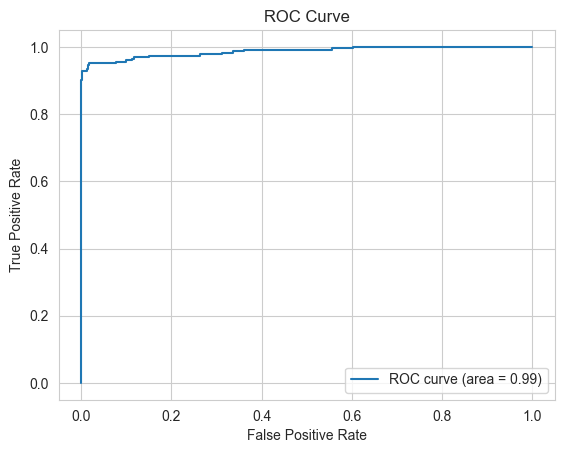

In [97]:
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.plot(
    false_positive_rate, true_positive_rate, label="ROC curve (area = %0.2f)" % roc_auc
)
plt.legend(loc="lower right")
plt.show()

In [95]:
roc_auc

np.float64(0.9862556728492502)

## Using Naive Bernoulli classifier

In [98]:
# Instantiating using Naive Bernoulli
bnb = naive_bayes.BernoulliNB()

# fitting

bnb.fit(X_train_transformed, y_train)

## Predictions and probability

y_test_predicted_binomial = bnb.predict(X_test_transformed)

# Probabilities

probabilities_binomial = bnb.predict_proba(X_test_transformed)

## Bernoulli Model Evaluation

In [99]:
# Accuracy
metrics.accuracy_score(y_test, y_test_predicted_binomial)

0.9736842105263158

In [100]:
bnb

BernoulliNB()

### Confusion Matrix Bernoulli

In [101]:
metrics.confusion_matrix(y_test, y_test_predicted_binomial)

array([[1447,    1],
       [  43,  181]])

In [102]:
confusion2 = metrics.confusion_matrix(y_test, y_test_predicted_binomial)
TN = confusion2[0, 0]
FP = confusion2[0, 1]
FN = confusion2[1, 0]
TP = confusion2[1, 1]

### Binomial Sensitivity-Specificity Trade offs


In [103]:
# Sensitivity
sensitivity = float(TP / float(TP + FN))  # Out of all spams, how many are spams?
print("Sensitivity:", sensitivity)

Sensitivity: 0.8080357142857143


In [104]:
# specifity
specificity = float(TN / float(TN + FP))
print("Specificity:", specificity)

Specificity: 0.9993093922651933


**Business objectives govern our model evaluation and selection? In this case, you wanted the False positives i.e the ham being classified as spam as low as possible which you could achieve by using Bernoulli Naive Bayes classifier even though the overall accuracy and sensitivity was less than Multinomial Naive Bayes classifier.**

### Binomial Precision Recall Tradeoffs

In [105]:
precision = float(TP / (TP + FP))
print(
    "Precision Score:",
    metrics.precision_score(y_test, y_test_predicted_binomial),
    precision,
)
print("Recall Score: ", metrics.recall_score(y_test, y_test_predicted_binomial))
print("F1 Score: ", metrics.f1_score(y_test, y_test_predicted_binomial))

Precision Score: 0.9945054945054945 0.9945054945054945
Recall Score:  0.8080357142857143
F1 Score:  0.8916256157635468
